In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv("/workspaces/Aress_Task/data/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df=df.drop(['CustomerID'],axis=1)

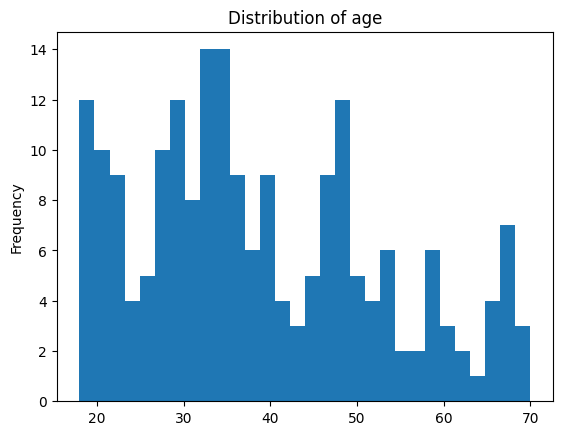

In [8]:
df['Age'].plot(
    kind='hist',
    bins=30
)
plt.title("Distribution of age")
plt.show()

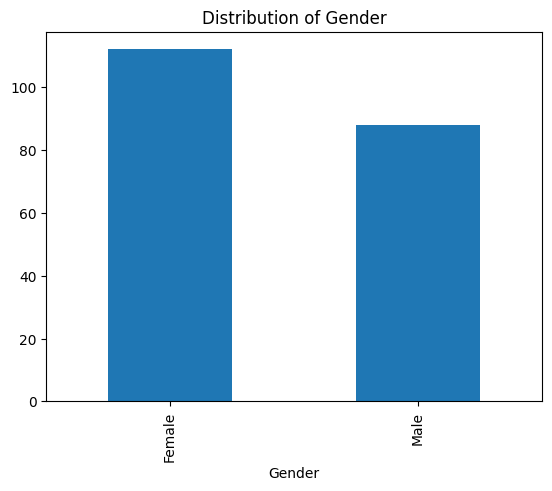

In [9]:
df['Gender'].value_counts().plot(
    kind='bar'
)
plt.title("Distribution of Gender")
plt.show()

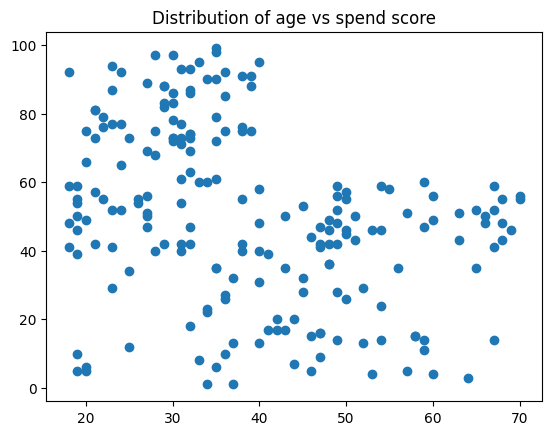

In [10]:
x=df['Age']
y=df['Spending Score (1-100)']
plt.scatter(x,y)
plt.title('Distribution of age vs spend score')
plt.show()

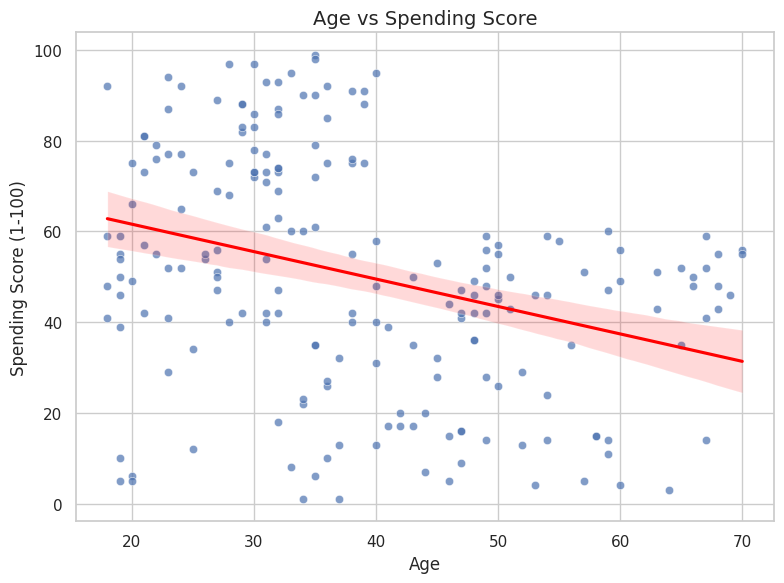

In [11]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Age'], 
    y=df['Spending Score (1-100)'],
    alpha=0.7
)

# Add regression line
sns.regplot(
    x=df['Age'], 
    y=df['Spending Score (1-100)'],
    scatter=False, 
    color='red'
)

plt.title('Age vs Spending Score', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:

label_encd=LabelEncoder()
df['Gender']=label_encd.fit_transform(df['Gender'])

In [14]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


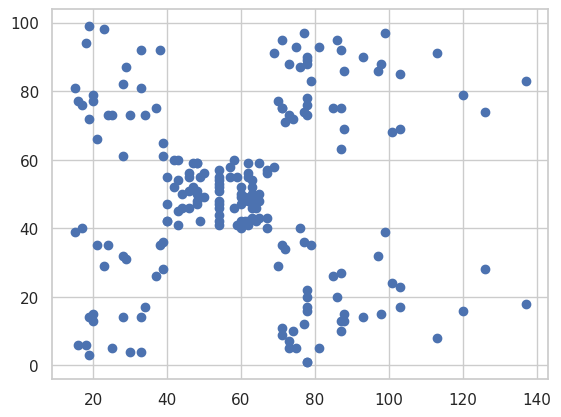

In [15]:
plt.scatter(x=df['Annual Income (k$)'],y=df['Spending Score (1-100)'])
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled=scaler.fit_transform(df)



In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
	kmeans = KMeans(n_clusters=k, random_state=42, n_init=25)
	kmeans.fit(df_scaled)
	inertias.append(kmeans.inertia_)
	
	score = silhouette_score(df_scaled, kmeans.labels_)
	silhouette_scores.append(score)


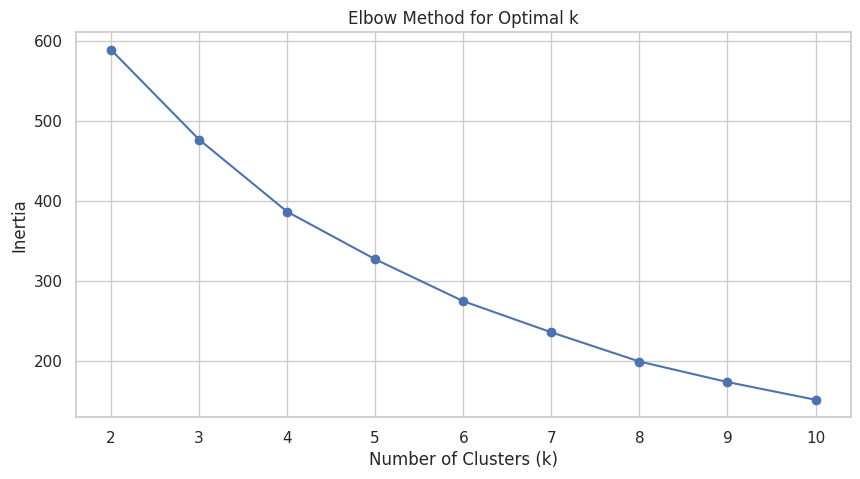

In [19]:

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


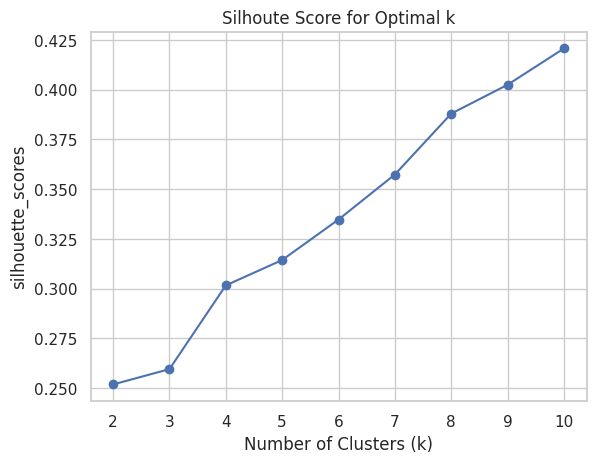

In [20]:

plt.plot(K_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('silhouette_scores')
plt.title('Silhoute Score for Optimal k')
plt.grid(True)
plt.show()


In [21]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

## K value based on the above graphs 
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=25)
labels = kmeans.fit_predict(df_scaled)


In [ ]:
## t-SNE

tsne = TSNE(n_components=2, perplexity=30,random_state=42, init='pca')
tsne_results = tsne.fit_transform(df_scaled)


tsne_df = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = labels


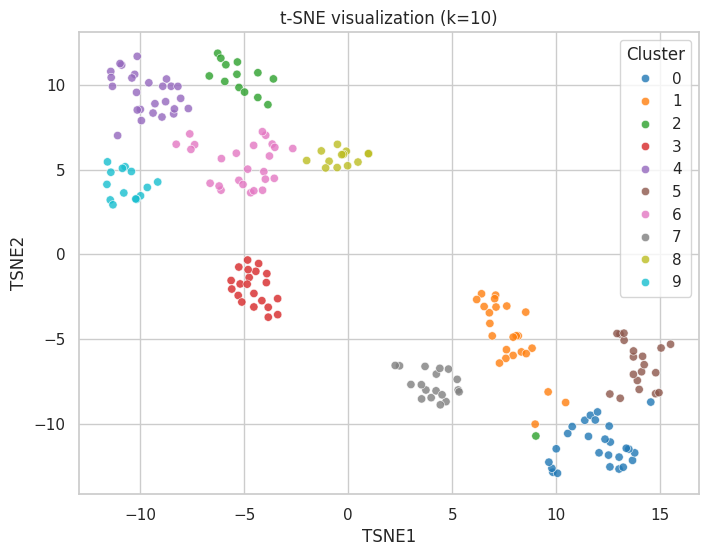

In [ ]:

plt.figure(figsize=(8,6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', alpha=0.8)
plt.title(f"t-SNE visualization (k={k})")
plt.legend(title='Cluster')
plt.show()

In [ ]:

import umap.umap_ as umap

umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = umap_reducer.fit_transform(df_scaled)

umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1','UMAP2'])
umap_df['Cluster'] = labels


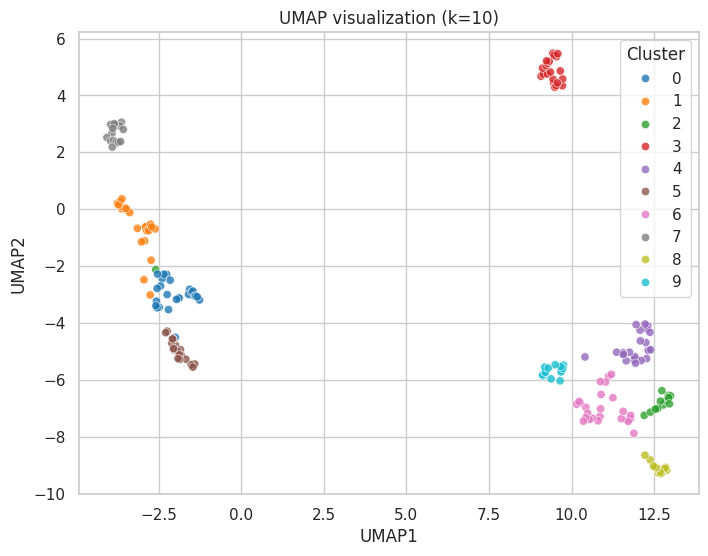

In [23]:

plt.figure(figsize=(8,6))
palette = 'tab20' if k and k > 10 else 'tab10'
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Cluster', palette=palette, alpha=0.8)
plt.title(f"UMAP visualization (k={k})")
plt.legend(title='Cluster')
plt.show()